In [118]:
import pandas as pd
import numpy as np
data = pd.read_csv("Weather-2020-2025.csv")
data.head()




,location_id,time,temperature_2m,relative_humidity_2m (%),wind_speed_10m (km/h),precipitation (mm),is_day,wind_speed_100m (km/h),wind_gusts_10m (km/h),wind_direction_100m,wind_direction_10m,cloud_cover (%),vapour_pressure_deficit (kPa)
0,0,2024-01-01T00:00,7.7,77,30.6,0.0,0,48.2,51.8,246,243,90,0.25
1,0,2024-01-01T01:00,7.6,77,29.5,0.0,0,47.4,50.8,249,246,60,0.24
2,0,2024-01-01T02:00,7.3,78,29.0,0.0,0,47.0,49.3,248,245,22,0.22
3,0,2024-01-01T03:00,7.0,80,26.8,0.0,0,44.1,48.2,251,248,33,0.20
4,0,2024-01-01T04:00,6.9,80,26.0,0.0,0,42.7,44.6,254,251,46,0.20


In [119]:
data['time'] = pd.to_datetime(data['time'])
data.tail()



,location_id,time,temperature_2m,relative_humidity_2m (%),wind_speed_10m (km/h),precipitation (mm),is_day,wind_speed_100m (km/h),wind_gusts_10m (km/h),wind_direction_100m,wind_direction_10m,cloud_cover (%),vapour_pressure_deficit (kPa)
52627,2,2025-12-31 19:00:00,10.4,86,6.1,0.0,0,13.0,11.9,65,45,100,0.17
52628,2,2025-12-31 20:00:00,10.4,87,5.7,0.0,0,13.1,11.9,77,58,100,0.17
52629,2,2025-12-31 21:00:00,10.6,87,5.5,0.0,0,13.3,11.2,91,67,100,0.16
52630,2,2025-12-31 22:00:00,10.5,89,9.0,0.0,0,19.8,16.2,106,91,100,0.14
52631,2,2025-12-31 23:00:00,10.1,87,10.1,0.0,0,21.9,19.8,104,87,100,0.16


In [120]:
data["location_id"]=data["location_id"].replace({0: "London", 1:"Dublin" , 2:"Lisbon"})
display(data.tail())


,location_id,time,temperature_2m,relative_humidity_2m (%),wind_speed_10m (km/h),precipitation (mm),is_day,wind_speed_100m (km/h),wind_gusts_10m (km/h),wind_direction_100m,wind_direction_10m,cloud_cover (%),vapour_pressure_deficit (kPa)
52627,Lisbon,2025-12-31 19:00:00,10.4,86,6.1,0.0,0,13.0,11.9,65,45,100,0.17
52628,Lisbon,2025-12-31 20:00:00,10.4,87,5.7,0.0,0,13.1,11.9,77,58,100,0.17
52629,Lisbon,2025-12-31 21:00:00,10.6,87,5.5,0.0,0,13.3,11.2,91,67,100,0.16
52630,Lisbon,2025-12-31 22:00:00,10.5,89,9.0,0.0,0,19.8,16.2,106,91,100,0.14
52631,Lisbon,2025-12-31 23:00:00,10.1,87,10.1,0.0,0,21.9,19.8,104,87,100,0.16


In [121]:
data.groupby("location_id")["temperature_2m"].min()
lowest_temp_value=data.groupby("location_id")["temperature_2m"].min()
lowest_temp_location=lowest_temp_value.idxmin()
lowest_temp_value=lowest_temp_value.min()
print(f"location with the lowest temperature: {lowest_temp_location}(total: {lowest_temp_value})")

location with the lowest temperature: London(total: -5.1)


In [122]:
data.groupby('location_id')['temperature_2m'].mean()
#lowest average temperature

,temperature_2m
location_id,
Dublin,11.225325
Lisbon,17.464449
London,12.069300


In [123]:
data.groupby("location_id")["precipitation (mm)"].sum()
#lowest average precipitation
lowest_p_value=data.groupby("location_id")["precipitation (mm)"].sum()
lowest_p_location=lowest_p_value.idxmin()
lowest_p_value=lowest_p_value.min()
print(f"location with the lowest precipitation: {lowest_p_location}(total: {lowest_p_value})")

location with the lowest precipitation: London(total: 1507.0)


In [124]:
#highest wind speed at 100m
avg_wind=data.groupby("location_id")["wind_speed_100m (km/h)"].mean()
max_location = avg_wind.idxmax()
max_speed = avg_wind.max()
print(f"Location with highest average wind speed: {max_location}(total: {max_speed}km/h)")



Location with highest average wind speed: Dublin(total: 25.924304605563155km/h)


In [125]:
#most consistent wind direction at 100m
def directional_consistency(x):
    rad = np.deg2rad(x.dropna())
    return np.sqrt(
        np.mean(np.cos(rad))**2 +
        np.mean(np.sin(rad))**2
    )

consistency = (
    data.groupby("location_id")["wind_direction_100m"]
        .apply(directional_consistency)
)

best_location = consistency.idxmax()
best_score = consistency.max()

print(f"Most consistent wind direction: {best_location}")
print(f"Consistency score: {best_score:.4f}")

Most consistent wind direction: Lisbon
Consistency score: 0.3905


In [126]:
import matplotlib.pyplot as plt
import numpy as np

In [127]:
plt.ioff()


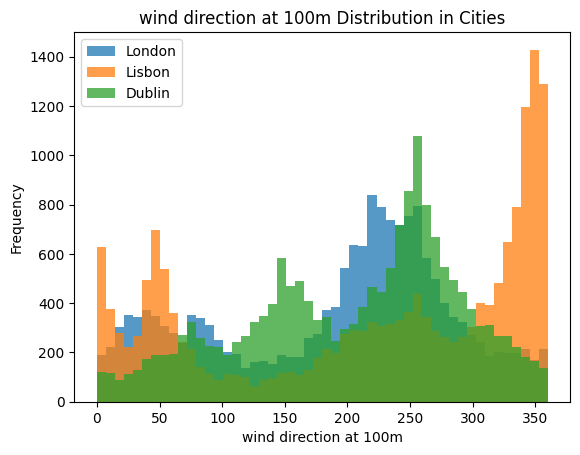

In [128]:
#histogram for wind direction of each city overlapping

fig = plt.figure()
london = data[data["location_id"] == "London"].copy()

dublin = data[data["location_id"] == "Dublin"].copy()

lisbon = data[data["location_id"] == "Lisbon"].copy()
bins = 50
plt.hist(london["wind_direction_100m"], bins=bins, label="London", alpha = 0.75)
plt.hist(lisbon["wind_direction_100m"], bins=bins, label="Lisbon", alpha = 0.75)
plt.hist(dublin["wind_direction_100m"], bins=bins, label="Dublin", alpha = 0.75)

plt.xlabel("wind direction at 100m")
plt.ylabel("Frequency")
plt.title("wind direction at 100m Distribution in Cities")
plt.legend()
plt.show()

fig.savefig("wind_direction_distribution.png")




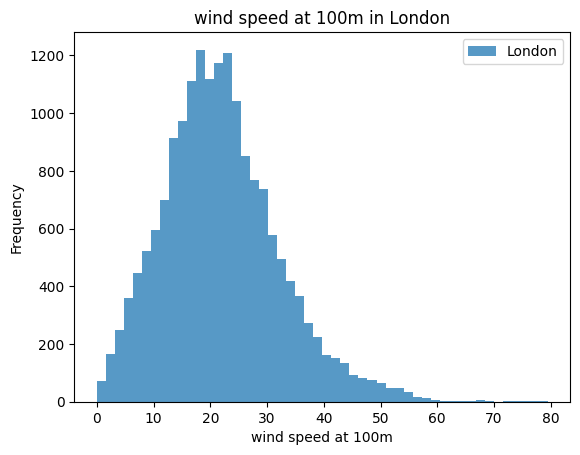

In [129]:
#wind speed distribution for each city
fig = plt.figure()
london = data[data["location_id"] == "London"].copy()
bins = 50
plt.hist(london["wind_speed_100m (km/h)"], bins=bins, label="London", alpha = 0.75)
plt.xlabel("wind speed at 100m")
plt.ylabel("Frequency")
plt.title("wind speed at 100m in London")
plt.legend()
plt.show()

fig.savefig("wind_speed_london.png")

Month
1      5.550874
2      7.636404
3      8.313441
4      9.926111
5     13.015927
6     14.591181
7     16.110618
8     16.628696
9     13.469653
10    11.868145
11     9.147986
12     8.227487
Name: temperature_2m, dtype: float64


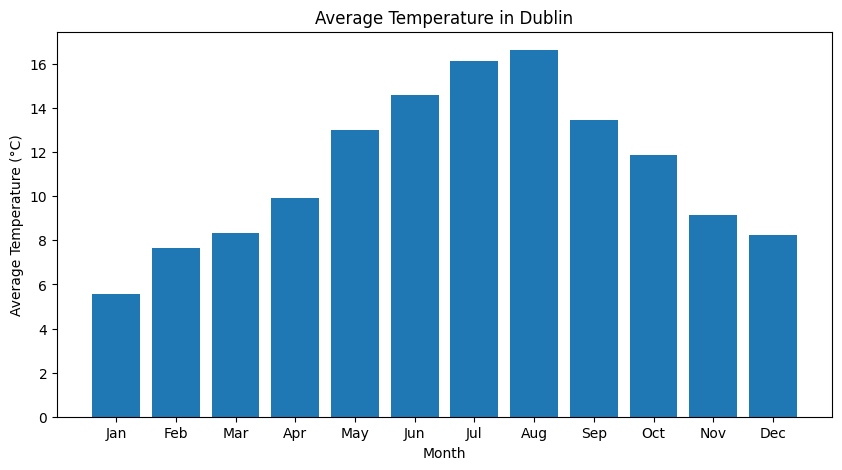

In [130]:
# Bar chart for the average temperature each month in Dublin
dublin = data[data['location_id'] == "Dublin"].copy()

dublin["Month"] = dublin["time"].dt.month


mean_temp_month = dublin.groupby("Month")["temperature_2m"].mean()

print(mean_temp_month)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig = plt.figure(figsize=(10,5))
plt.bar(month_labels, mean_temp_month.values)

plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.title("Average Temperature in Dublin")

plt.show()
fig.savefig("average_temperature_month.png")


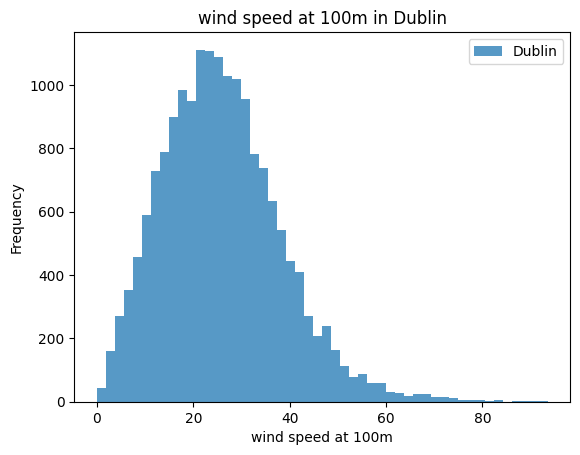

In [131]:
# histogram for wind speed at 100m distribution for dublin
fig = plt.figure()
dublin = data[data["location_id"] == "Dublin"].copy()
bins = 50
plt.hist(dublin["wind_speed_100m (km/h)"], bins=bins, label="Dublin", alpha = 0.75)
plt.xlabel("wind speed at 100m")
plt.ylabel("Frequency")
plt.title("wind speed at 100m in Dublin")
plt.legend()
plt.show()

fig.savefig("wind_speed_dublin.png")


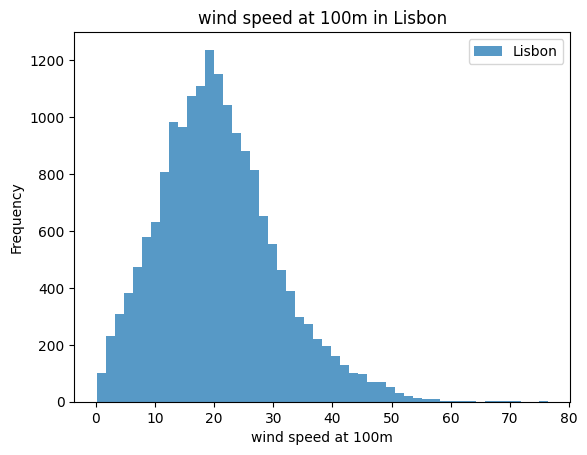

In [132]:
#wind speed distribution at 100m for Lisbon
fig = plt.figure()
lisbon = data[data["location_id"] == "Lisbon"].copy()
bins = 50
plt.hist(lisbon["wind_speed_100m (km/h)"], bins=bins, label="Lisbon", alpha = 0.75)
plt.xlabel("wind speed at 100m")
plt.ylabel("Frequency")
plt.title("wind speed at 100m in Lisbon")
plt.legend()
plt.show()

fig.savefig("wind_speed_lisbon.png")


In [133]:
data.groupby('location_id')['precipitation (mm)'].mean()

,precipitation (mm)
location_id,
Dublin,0.122435
Lisbon,0.089546
London,0.085898
